In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

In [7]:
def init_r(N, kind="uniform", scale=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if kind == "uniform":
        return rng.uniform(-scale, scale, size=N)
    if kind == "gaussian":
        return rng.normal(0.0, scale, size=N)
    if kind == "zeros":
        return np.zeros(N)
    if kind == "ones":
        return np.ones(N)

    raise ValueError("kind must be 'uniform', 'gaussian', 'zeros', or 'ones'")


def make_W(N, J, rng, kind="gaussian", p=None):
    if kind == "gaussian":
        return rng.normal(0.0, J / np.sqrt(N), size=(N, N))

    if kind == "erdos_renyi":
        if p is None:
            raise ValueError("need p")
        k = max(int(p * N), 1)
        return ((rng.random((N, N)) < p) * (J / k)).astype(float)

    raise ValueError("kind must be 'gaussian' or 'erdos_renyi'")


def simulate(r_0, W, time):
    r_0 = np.asarray(r_0, dtype=float)
    W  = np.asarray(W, dtype=float)

    dt = time[1] - time[0]
    T  = len(time)
    N  = len(r_0)

    R = np.empty((T, N))
    R[0] = r_0

    for t in range(T - 1):
        r = R[t]
        R[t + 1] = r + dt * (-r + np.tanh(W @ r))  # fully vectorized

    return R

In [8]:
def plot_dynamics(N=300, Js=(0.7, 0.95, 1.0, 1.5), seed=None, erdos_p=None):
    rng = np.random.default_rng(seed) 
    time = np.linspace(0, 20, 400)
    r_0 = init_r(N, rng=rng)
    fig, axes = plt.subplots(1, len(Js), figsize=(4 * len(Js), 4))

    for ax, J in zip(axes, Js):
        kind = "erdos_renyi" if erdos_p != None else "gaussian"
        W = make_W(N, J, rng=rng, kind=kind, p=erdos_p)
        R = simulate(r_0, W, time)
        ax.plot(time, R[:, :8], lw=0.9, alpha=0.85)
        ax.set_title(f"J = {J}")
        ax.set_xlabel("time")
        ax.set_ylabel("r(t)")
    plt.tight_layout()
    plt.show()


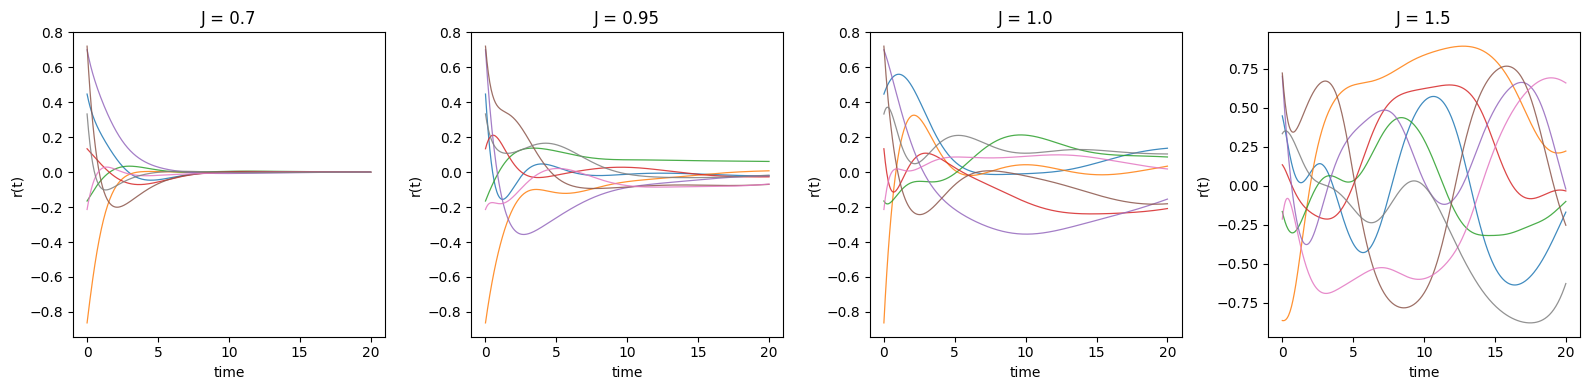

In [9]:
plot_dynamics() # gaussian W

For $J < 1$, all neuron trajectories decay to zero and the rate distribution collapses to a delta at the origin, consistent with a stable fixed point. For $J > 1$, instead, trajectories display persistent irregular oscillations and the distribution remains broad over time, signalling the onset of chaos. The transition is sharp at $J_c = 1$.

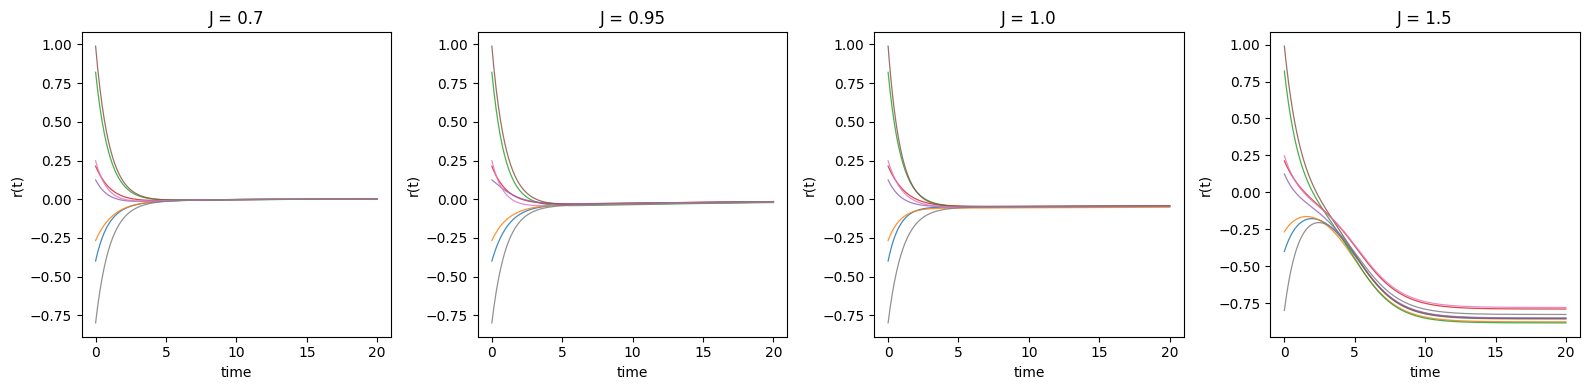

In [10]:
plot_dynamics(erdos_p=0.3) # erdos case

Critical coupling is effectively shifted: sparse connectivity (small p) suppresses chaos, so the network can converge to a stable fixed point even for $J_c > 1$.

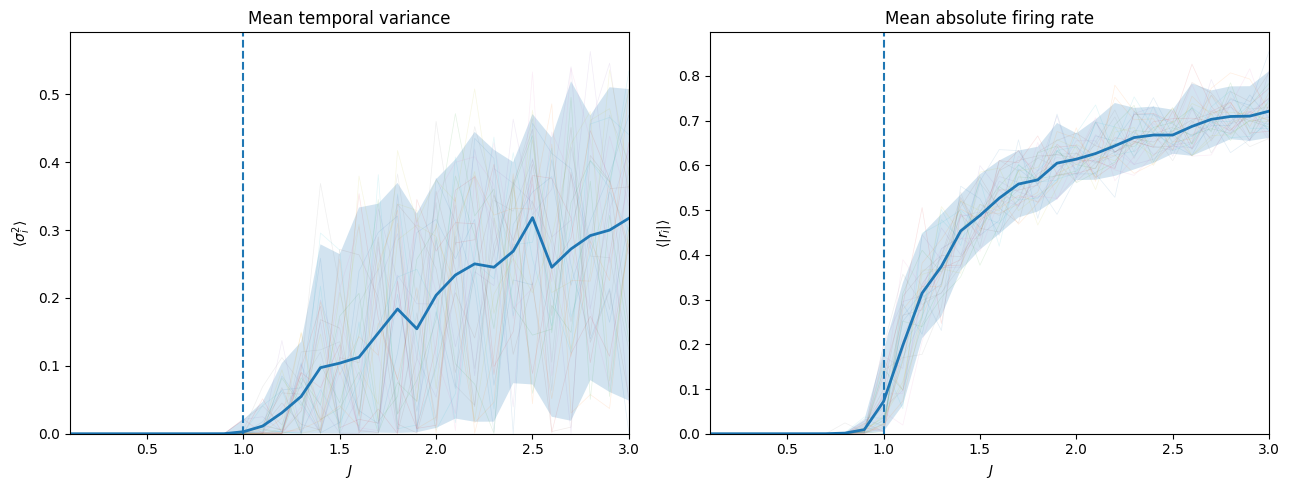

In [11]:
N        = 100
time     = np.linspace(0, 40, 800)
J_values = np.round(np.arange(0.1, 3.01, 0.1), 2)
N_TRIALS = 30
half     = len(time) // 2

all_vars  = np.empty((len(J_values), N_TRIALS))
all_means = np.empty((len(J_values), N_TRIALS))

for j_idx, J in enumerate(J_values):
    for trial in range(N_TRIALS):
        rng = np.random.default_rng(j_idx * 1000 + trial)

        R = simulate(
            init_r(N, rng=rng),
            make_W(N, J, rng=rng),
            time
        )

        R_ss = R[half:]
        all_vars[j_idx, trial]  = R_ss.var(axis=0).mean()
        all_means[j_idx, trial] = np.abs(R_ss).mean()

def ribbon(x):
    return x.mean(1), np.percentile(x, 5, 1), np.percentile(x, 95, 1)

var_mu, var_lo, var_hi     = ribbon(all_vars)
mean_mu, mean_lo, mean_hi  = ribbon(all_means)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, mu, lo, hi, ylabel, title in zip(
    axes,
    [all_vars, all_means],
    [var_mu, mean_mu],
    [var_lo, mean_lo],
    [var_hi, mean_hi],
    [r"$\langle \sigma^2_i \rangle$", r"$\langle |r_i| \rangle$"],
    ["Mean temporal variance", "Mean absolute firing rate"],
):
    ax.fill_between(J_values, lo, hi, alpha=0.2)
    ax.plot(J_values, data, lw=0.5, alpha=0.12)   # all trials at once (vectorized)
    ax.plot(J_values, mu, lw=2)
    ax.axvline(1.0, ls="--")

    ax.set(xlabel="$J$", ylabel=ylabel, title=title, xlim=(J_values[0], J_values[-1]))
    ax.set_ylim(bottom=0)

plt.tight_layout()

Mean temporal variance $\langle \sigma_i^2 \rangle$ remains numerically zero for $J < 1$,
confirming that all trajectories converge to a fixed point in the sub-critical regime.
It rises continuously past $J_c = 1$, consistent with a second-order phase transition.
The large trial-to-trial variability (wide ribbon) for $J > 1$ reflects sensitivity to
initial conditions and random connectivity — individual realisations fluctuate strongly
around a monotonically increasing mean.

Mean absolute firing rate $\langle |r_i| \rangle$ is also zero for $J < 1$, then grows
steeply just above $J_c = 1$ before saturating toward $\sim 0.7$ at large $J$.
The saturation is expected: neuron outputs are bounded by $\tanh$, so rates cannot grow
unboundedly. Compared to the variance, this observable has a much narrower ribbon,
indicating it is more self-averaging and less sensitive to the specific realisation of $W$.

Jointly, the two panels paint a consistent picture of the chaos transition: the firing
rate detects that activity is *nonzero*, while the variance detects that it is
*fluctuating*. Both switch on at the same $J_c = 1$, in agreement with the theoretical
prediction for Gaussian random networks.

In [12]:
N=25
dt       = 0.05
T_total  = 80.0           # long run for good frequency resolution
time     = np.arange(0, T_total, dt)
T        = len(time)
half     = T // 2         # discard transient — only FFT the second half
N_TRIALS = 5              # independent (r0, W) draws averaged per J

J_values = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]

# frequency axis for the steady-state window
freqs = np.fft.rfftfreq(T - half, d=dt)   # cycles per time-unit

n_freqs   = len(freqs)
psd_all   = np.zeros((len(J_values), n_freqs))   # averaged over trials & neurons

for j_idx, J in enumerate(J_values):
    trial_psd = np.zeros(n_freqs)
    for trial in range(N_TRIALS):
        rng  = np.random.default_rng(j_idx * 500 + trial)
        X0   = init_r(N, rng=rng)
        W    = make_W(N, J, rng=rng)
        R    = simulate(X0, W, time)        # (T, N)
        R_ss = R[half:, :]                  # steady-state: (T/2, N)

        # FFT every neuron, accumulate power
        fft_mat   = np.fft.rfft(R_ss, axis=0)          # (n_freqs, N)
        power_mat = (np.abs(fft_mat) ** 2) / (T - half) # normalise
        trial_psd += power_mat.mean(axis=1)             # average over neurons

    psd_all[j_idx] = trial_psd / N_TRIALS

# find dominant, mean, and variance of frequency per J

psd_ac = psd_all[:, 1:]     # drop DC
f_ac   = freqs[1:]

dominant_freqs = f_ac[np.argmax(psd_ac, axis=1)]

# spectral mean and variance (weighted by power)
def spectral_mean(psd_row, f):
    w = psd_row / psd_row.sum()
    return np.sum(w * f)

def spectral_var(psd_row, f):
    w  = psd_row / psd_row.sum()
    mu = np.sum(w * f)
    return np.sum(w * (f - mu) ** 2)

mean_freqs = np.array([spectral_mean(psd_ac[j], f_ac) for j in range(len(J_values))])
var_freqs  = np.array([spectral_var (psd_ac[j], f_ac) for j in range(len(J_values))])

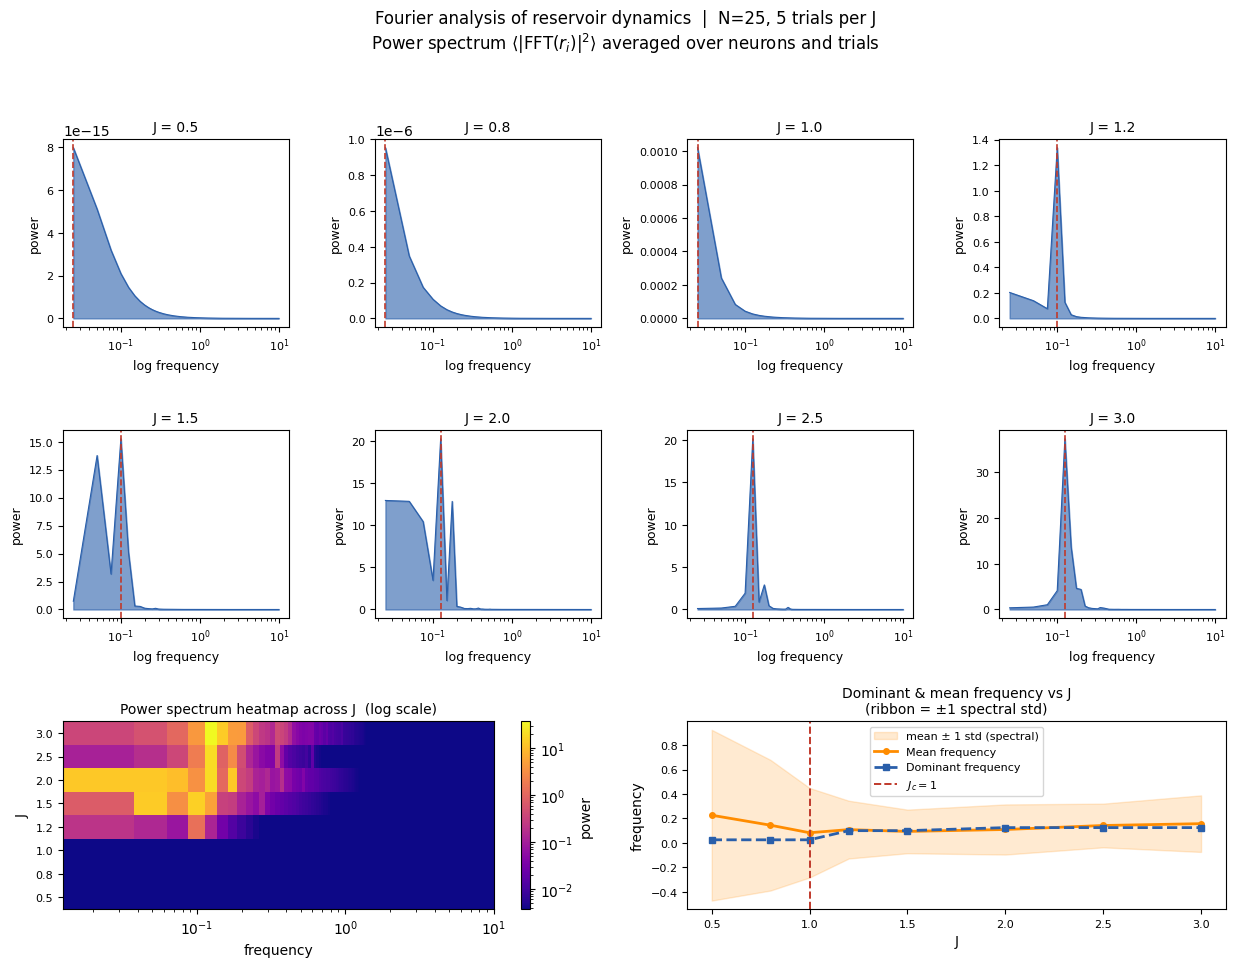

In [13]:
CMAP  = "plasma"
RED   = "#c0392b"
BLUE  = "#2a5faa"

fig = plt.figure(figsize=(15, 10))
fig.suptitle(
    f"Fourier analysis of reservoir dynamics  |  N={N}, {N_TRIALS} trials per J\n"
    r"Power spectrum $\langle |$FFT$(r_i)|^2 \rangle$ averaged over neurons and trials",
    fontsize=12, y=1.01
)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)


for j_idx, J in enumerate(J_values[:4]):
    ax = fig.add_subplot(gs[0, j_idx])
    psd = psd_all[j_idx]
    f_plot = freqs[1:]
    ax.fill_between(f_plot, psd[1:], alpha=0.6, color=BLUE)
    ax.plot(f_plot, psd[1:], lw=0.8, color=BLUE)
    dom = dominant_freqs[j_idx]
    ax.axvline(dom, color=RED, lw=1.2, ls="--")
    ax.set_xscale("log")
    ax.set_title(f"J = {J}", fontsize=10)
    ax.set_xlabel("log frequency", fontsize=9)
    ax.set_ylabel("power", fontsize=9)
    ax.tick_params(labelsize=8)

for j_idx, J in enumerate(J_values[4:]):
    ax = fig.add_subplot(gs[1, j_idx])
    psd = psd_all[j_idx + 4]
    f_plot = freqs[1:]
    ax.fill_between(f_plot, psd[1:], alpha=0.6, color=BLUE)
    ax.plot(f_plot, psd[1:], lw=0.8, color=BLUE)
    dom = dominant_freqs[j_idx + 4]
    ax.axvline(dom, color=RED, lw=1.2, ls="--")
    ax.set_xscale("log")
    ax.set_title(f"J = {J}", fontsize=10)
    ax.set_xlabel("log frequency", fontsize=9)
    ax.set_ylabel("power", fontsize=9)
    ax.tick_params(labelsize=8)

#heatmap
ax_heat = fig.add_subplot(gs[2, :2])
freq_mask = freqs > 0
im = ax_heat.pcolormesh(
    freqs[freq_mask],
    np.arange(len(J_values)),
    psd_all[:, freq_mask],
    norm=LogNorm(vmin=psd_all[:, freq_mask].max() * 1e-4,
                 vmax=psd_all[:, freq_mask].max()),
    cmap=CMAP,
    shading="auto"
)
ax_heat.set_xscale("log") 
ax_heat.set_yticks(np.arange(len(J_values)))
ax_heat.set_yticklabels([f"{J}" for J in J_values], fontsize=8)
ax_heat.set_xlabel("frequency", fontsize=10)
ax_heat.set_ylabel("J", fontsize=10)
ax_heat.set_title("Power spectrum heatmap across J  (log scale)", fontsize=10)
plt.colorbar(im, ax=ax_heat, label="power")

# dominant and mean freq
ax_dom = fig.add_subplot(gs[2, 2:])

std_freqs = np.sqrt(var_freqs)

# variance ribbon around mean
ax_dom.fill_between(J_values,
                    mean_freqs - std_freqs,
                    mean_freqs + std_freqs,
                    alpha=0.18, color="darkorange", label="mean ± 1 std (spectral)")

ax_dom.plot(J_values, mean_freqs, lw=2, color="darkorange",
            marker="o", markersize=4, label="Mean frequency")
ax_dom.plot(J_values, dominant_freqs, lw=2, color=BLUE,
            marker="s", markersize=4, ls="--", label="Dominant frequency")

ax_dom.axvline(1.0, color=RED, lw=1.4, ls="--", label="$J_c = 1$")
ax_dom.set_xlabel("J", fontsize=10)
ax_dom.set_ylabel("frequency", fontsize=10)
ax_dom.set_title("Dominant & mean frequency vs J\n(ribbon = ±1 spectral std)", fontsize=10)
ax_dom.legend(fontsize=8)
ax_dom.tick_params(labelsize=8)

plt.show()

For $J < 1$, power is concentrated at very low frequencies (slow decay to zero, no oscillatory content). Near $J_c = 1$, a dominant frequency emerges. For $J ≫ 1$, the PSD sharpens around a well-defined peak, indicating that the chaotic fluctuations become increasingly periodic. The heatmap makes this transition visible across the full $J$ range: the power migrates from the DC component toward finite frequencies as $J$ crosses $1$.
